### Imports

In [5]:
import warnings
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm

from src.config import CONFIG
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer
from src.utils import get_random_audio

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [6]:
INPUT_DIR = Path('../../data/audioMNIST')

### Visualising audio data as Mel Spectograms

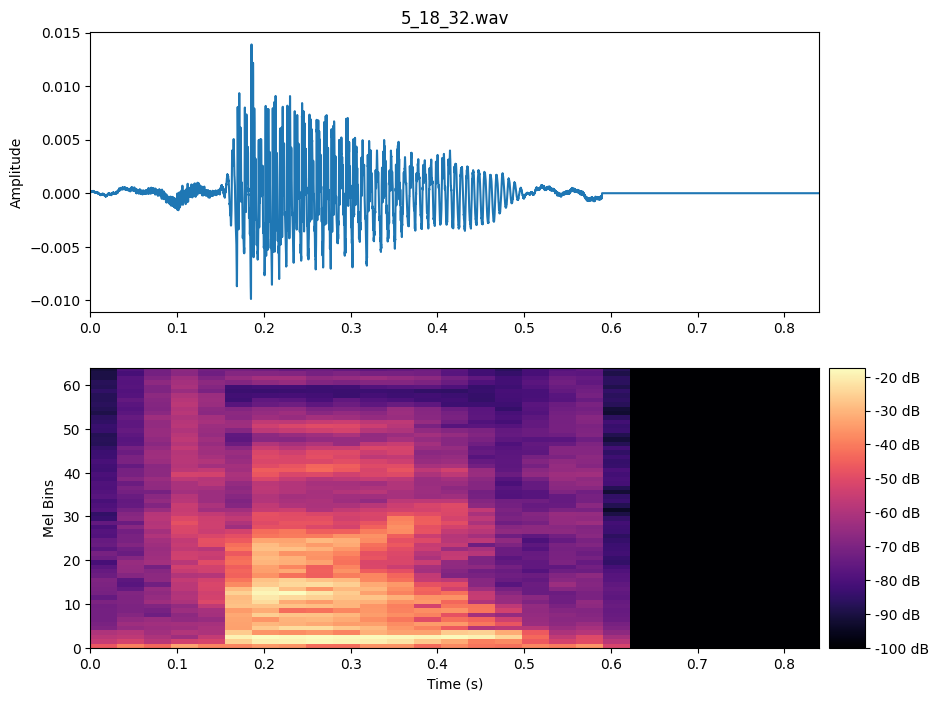

Original: 28308 samples (0.59s)
Preprocessed: 13440 samples (0.84s)


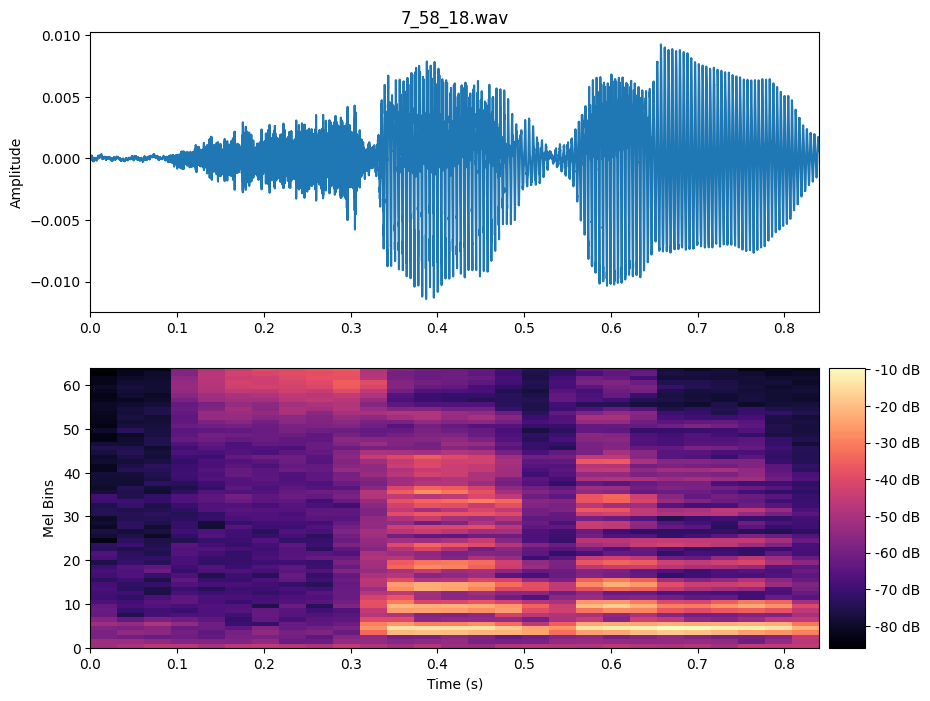

Original: 46223 samples (0.96s)
Preprocessed: 13440 samples (0.84s)


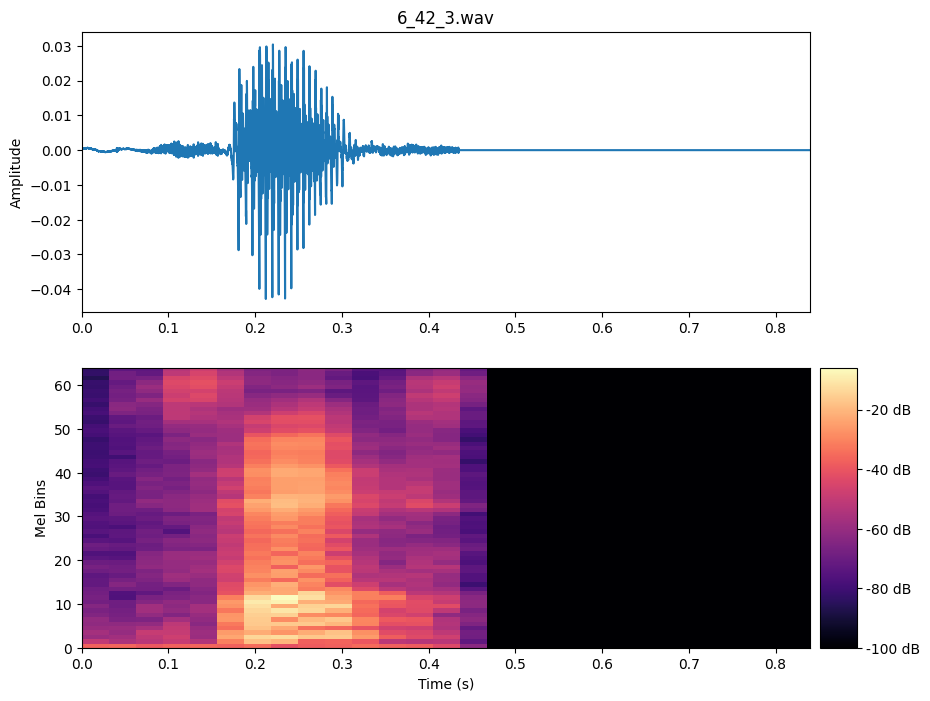

Original: 20864 samples (0.43s)
Preprocessed: 13440 samples (0.84s)


In [7]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer(filterbank='mel')

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        mel_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / CONFIG.audio.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file.name)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Mel Spectrogram
        img = ax2.imshow(
            mel_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[0, new_duration, 0, CONFIG.audio.n_mels],
        )
        ax2.set_ylabel('Mel Bins')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=CONFIG.audio.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()

### Determining the 95th percentile for audio lengths
Use this to determine the best value to pad/truncate audio files to.

30000it [00:05, 5543.91it/s]


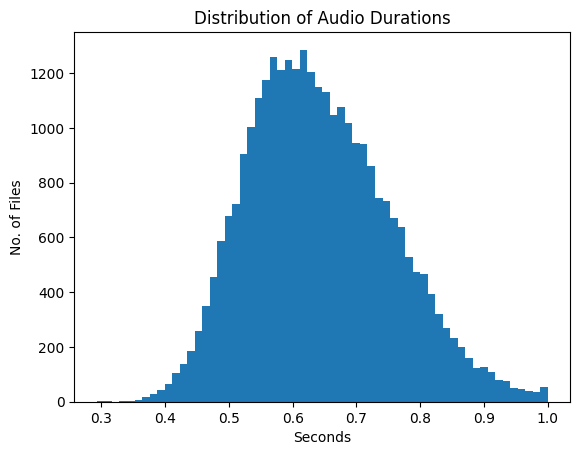

95% Percentile: 0.84s


In [8]:
def calculate_audio_lengths() -> None:
    audio_files = INPUT_DIR.rglob('*.wav')

    durations = []
    for file in tqdm(audio_files):
        info = torchaudio.info(file)
        duration = info.num_frames / info.sample_rate
        durations.append(duration)

    durations = np.array(durations)

    plt.hist(durations, bins=60)
    plt.title('Distribution of Audio Durations')
    plt.xlabel('Seconds')
    plt.ylabel('No. of Files')
    plt.show()

    print(f'95% Percentile: {np.percentile(durations, 95):.2f}s')
calculate_audio_lengths()